In [1]:
from pathlib import Path

for item in Path("/kaggle/input").iterdir():
    print(item)

/kaggle/input/datasets


In [2]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets")

print("Contents of dataset:")
for item in DATA_DIR.iterdir():
    print(item)

Contents of dataset:
/kaggle/input/datasets/preetpalsingh25


In [3]:
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/preetpalsingh25")

print("Contents:")
for item in DATA_DIR.iterdir():
    print(item)

Contents:
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images


In [4]:
from pathlib import Path
from PIL import Image
from collections import Counter

DATA_DIR = Path(
    "/kaggle/input/datasets/preetpalsingh25/"
    "alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset"
)

print("Dataset:", DATA_DIR)

print("\nDataset contents:")
for item in DATA_DIR.iterdir():
    print(" ", item)


# ============================================================
# CHECK FOLDER STRUCTURE
# ============================================================

print("\nDataset contents:")
for item in DATA_DIR.iterdir():
    print(" ", item)


# ============================================================
# COUNT IMAGES
# ============================================================

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def count_images(split):

    split_dir = DATA_DIR / split
    counts = {}

    for class_dir in sorted(split_dir.iterdir()):

        if class_dir.is_dir():

            files = [
                f for f in class_dir.iterdir()
                if f.suffix.lower() in IMAGE_EXTENSIONS
            ]

            counts[class_dir.name] = len(files)

    return counts


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

all_counts = {}

for split in ["train", "test"]:

    print("\n" + "=" * 55)
    print(f"{split.upper()} DATASET")
    print("=" * 55)

    counts = count_images(split)
    all_counts[split] = counts

    total = sum(counts.values())

    for cls, n in counts.items():

        percentage = 100 * n / total

        print(f"{cls:20s}: {n:5d} images ({percentage:5.1f}%)")

    print("-" * 55)
    print(f"{'Total':20s}: {total:5d}")


# ============================================================
# IMAGE SIZE AND MODE CHECK
# ============================================================

def inspect_images(split, samples_per_class=20):

    sizes = Counter()
    modes = Counter()

    split_dir = DATA_DIR / split

    for class_dir in sorted(split_dir.iterdir()):

        if not class_dir.is_dir():
            continue

        files = [
            f for f in class_dir.iterdir()
            if f.suffix.lower() in IMAGE_EXTENSIONS
        ]

        # Inspect up to 20 images from EACH class
        for file in files[:samples_per_class]:

            try:
                with Image.open(file) as img:

                    sizes[img.size] += 1
                    modes[img.mode] += 1

            except Exception as e:

                print("Could not read:", file)
                print("Error:", e)

    return sizes, modes


sizes, modes = inspect_images("train")


# ============================================================
# PRINT IMAGE INFORMATION
# ============================================================

print("\n" + "=" * 55)
print("IMAGE SIZE CHECK")
print("=" * 55)

for size, count in sizes.items():
    print(f"{size}: {count} images")


print("\n" + "=" * 55)
print("IMAGE MODE CHECK")
print("=" * 55)

for mode, count in modes.items():
    print(f"{mode}: {count} images")


# ============================================================
# BASIC IMBALANCE CHECK
# ============================================================

print("\n" + "=" * 55)
print("CLASS IMBALANCE CHECK")
print("=" * 55)

train_counts = all_counts["train"]

largest = max(train_counts.values())
smallest = min(train_counts.values())

imbalance_ratio = largest / smallest

print(f"Largest class:  {largest}")
print(f"Smallest class: {smallest}")
print(f"Imbalance ratio: {imbalance_ratio:.2f} : 1")


print("\nStage 1 data exploration complete.")

Dataset: /kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset

Dataset contents:
  /kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test
  /kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train

Dataset contents:
  /kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test
  /kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train

TRAIN DATASET
MildDemented        :   896 images ( 14.0%)
ModerateDemented    :    64 images (  1.0%)
NonDemented         :  3200 images ( 50.0%)
VeryMildDemented    :  2240 images ( 35.0%)
-------------------------------------------------------
Total               :  6400

TEST DATASET
MildDemented        :   896 images ( 14.0%)
ModerateDemented    :    64 images (  1.0%)
NonDemented         :  3200 images ( 50.0%)
VeryMildDemented    : 

In [5]:
"""
Stage 1b: duplicate check between train and test.

Why: train and test showed identical class percentages, which is
a red flag for this specific dataset. If the same images (or
augmented copies of the same source image) appear in both splits,
any accuracy we report later is inflated and not trustworthy.

We hash each image's pixel content. Exact duplicates get the same
hash. This catches identical files; it will NOT catch augmented
versions (rotated/flipped) of the same source image, which is a
known limitation, but it is a fast first check.
"""

import hashlib
from pathlib import Path

DATA_DIR = Path(
    "/kaggle/input/datasets/preetpalsingh25/"
    "alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset"
)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def hash_file(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def collect_hashes(split):
    hashes = {}
    split_dir = DATA_DIR / split
    for class_dir in sorted(split_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for f in class_dir.iterdir():
            if f.suffix.lower() in IMAGE_EXTENSIONS:
                hashes[hash_file(f)] = (class_dir.name, f.name)
    return hashes

if __name__ == "__main__":
    train_hashes = collect_hashes("train")
    test_hashes = collect_hashes("test")

    overlap = set(train_hashes) & set(test_hashes)

    print(f"Train images: {len(train_hashes)}")
    print(f"Test images:  {len(test_hashes)}")
    print(f"Exact duplicate images between train and test: {len(overlap)}")

    if overlap:
        print("\nExample overlaps (train location -> test location):")
        for h in list(overlap)[:5]:
            print(f"  {train_hashes[h]} -> {test_hashes[h]}")

Train images: 6400
Test images:  6400
Exact duplicate images between train and test: 6400

Example overlaps (train location -> test location):
  ('VeryMildDemented', 'verymild_762.jpg') -> ('VeryMildDemented', 'verymild_762.jpg')
  ('NonDemented', 'non_1294.jpg') -> ('NonDemented', 'non_1294.jpg')
  ('NonDemented', 'non_2170.jpg') -> ('NonDemented', 'non_2170.jpg')
  ('NonDemented', 'non_1282.jpg') -> ('NonDemented', 'non_1282.jpg')
  ('MildDemented', 'mild_57.jpg') -> ('MildDemented', 'mild_57.jpg')


In [6]:
"""
Stage 2: create a real train/val/test split.

Why: the dataset's own "test" folder is a duplicate of "train"
(confirmed: 6400/6400 exact matches). So we treat "train" as the
entire pool (6400 unique images) and split it ourselves.

We use a 70/15/15 stratified split, meaning each class keeps the
same proportion in every split. This matters because ModerateDemented
only has 64 images total. A plain random split could easily put too
few (or by bad luck, zero) ModerateDemented images in test, making
that class's reported performance meaningless. Stratifying prevents
that.

Honest limitation to note in your writeup: even with stratification,
64 total images means roughly 45 train / 9-10 val / 9-10 test for
that class. A test result on 9 images is a noisy estimate, not a
solid one. This is worth stating directly rather than hiding it.

Output: three CSV manifests (train.csv, val.csv, test.csv) listing
file path and label. We don't copy image files, just record which
file belongs to which split, so nothing is duplicated on disk.
"""

import csv
from pathlib import Path
from sklearn.model_selection import train_test_split

DATA_DIR = Path(
    "/kaggle/input/datasets/preetpalsingh25/"
    "alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train"
)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
OUTPUT_DIR = Path("splits")
OUTPUT_DIR.mkdir(exist_ok=True)

def collect_files():
    records = []
    for class_dir in sorted(DATA_DIR.iterdir()):
        if not class_dir.is_dir():
            continue
        for f in class_dir.iterdir():
            if f.suffix.lower() in IMAGE_EXTENSIONS:
                records.append((str(f), class_dir.name))
    return records

def save_manifest(records, name):
    path = OUTPUT_DIR / f"{name}.csv"
    with open(path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filepath", "label"])
        writer.writerows(records)
    print(f"Saved {len(records)} records to {path}")

if __name__ == "__main__":
    records = collect_files()
    filepaths = [r[0] for r in records]
    labels = [r[1] for r in records]

    # First split off test (15%), stratified by label
    train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
        filepaths, labels, test_size=0.15, stratify=labels, random_state=42
    )

    # Then split train_val into train (70% of total) and val (15% of total)
    # 0.15 / 0.85 ≈ 0.1765 of the remaining data
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_val_paths, train_val_labels, test_size=0.1765,
        stratify=train_val_labels, random_state=42
    )

    save_manifest(list(zip(train_paths, train_labels)), "train")
    save_manifest(list(zip(val_paths, val_labels)), "val")
    save_manifest(list(zip(test_paths, test_labels)), "test")

    print("\nClass counts per split:")
    for name, labels_subset in [("train", train_labels), ("val", val_labels), ("test", test_labels)]:
        counts = {c: labels_subset.count(c) for c in sorted(set(labels))}
        print(f"{name}: {counts}")

Saved 4479 records to splits/train.csv
Saved 961 records to splits/val.csv
Saved 960 records to splits/test.csv

Class counts per split:
train: {'MildDemented': 627, 'ModerateDemented': 44, 'NonDemented': 2240, 'VeryMildDemented': 1568}
val: {'MildDemented': 135, 'ModerateDemented': 10, 'NonDemented': 480, 'VeryMildDemented': 336}
test: {'MildDemented': 134, 'ModerateDemented': 10, 'NonDemented': 480, 'VeryMildDemented': 336}


In [7]:
"""
Stage 3: baseline CNN, no generative augmentation yet.

We want an honest baseline number before adding anything to fix the
class imbalance further. This baseline already includes weighted
sampling, since training without it would almost certainly produce
a model that just predicts NonDemented most of the time.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"])
        img = transform(img)
        label = LABEL_TO_IDX[row["label"]]
        return img, label

def make_weighted_sampler(csv_path):
    df = pd.read_csv(csv_path)
    class_counts = df["label"].value_counts()
    weights = df["label"].apply(lambda c: 1.0 / class_counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    macro_f1 = f1_score(targets, preds, average="macro")
    return macro_f1, preds, targets

def train(epochs=15, batch_size=32, lr=1e-4):
    train_ds = MRIDataset("splits/train.csv")
    val_ds = MRIDataset("splits/val.csv")

    sampler = make_weighted_sampler("splits/train.csv")
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_f1, _, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pt")

    print(f"\nBest val macro-F1: {best_f1:.4f}")
    return model

if __name__ == "__main__":
    model = train()

    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)
    model.load_state_dict(torch.load("best_model.pt"))
    test_f1, preds, targets = evaluate(model, test_loader)

    print(f"\nTest macro-F1: {test_f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Epoch 1/15 | train loss: 0.4787 | val macro-F1: 0.8283
Epoch 2/15 | train loss: 0.1605 | val macro-F1: 0.7678
Epoch 3/15 | train loss: 0.0840 | val macro-F1: 0.9042
Epoch 4/15 | train loss: 0.0537 | val macro-F1: 0.8414
Epoch 5/15 | train loss: 0.0422 | val macro-F1: 0.9380
Epoch 6/15 | train loss: 0.0362 | val macro-F1: 0.8791
Epoch 7/15 | train loss: 0.0312 | val macro-F1: 0.9435
Epoch 8/15 | train loss: 0.0279 | val macro-F1: 0.9525
Epoch 9/15 | train loss: 0.0106 | val macro-F1: 0.9624
Epoch 10/15 | train loss: 0.0051 | val macro-F1: 0.9722
Epoch 11/15 | train loss: 0.0060 | val macro-F1: 0.9722
Epoch 12/15 | train loss: 0.0114 | val macro-F1: 0.8783
Epoch 13/15 | train loss: 0.0198 | val macro-F1: 0.9464
Epoch 14/15 | train loss: 0.0301 | val macro-F1: 0.9332
Epoch 15/15 | train loss: 0.0404 | val macro-F1: 0.9587

Best val macro-F1: 0.9722

Test macro-F1: 0.9741

Full classification report:
                  precision    recall  f1-score   support

    MildDemented       0.98    

In [8]:
"""
Stage 2b: near-duplicate check across our own split.

Why: the 97% macro-F1 with a perfect score on a 10-image test class
is suspicious, not reassuring. This exact dataset is known to contain
augmented copies of a smaller set of original images. Our earlier
exact-hash check only catches byte-identical files, it would miss a
rotated or flipped copy of the same source image. A perceptual hash
(phash) represents visual content, so near-identical images get
identical or very close hashes even after light augmentation.

If many perceptual-hash matches exist across train vs val/test, that
explains the suspiciously high score, and we need to re-split by
similarity group instead of by individual file.
"""

import pandas as pd
import imagehash
from PIL import Image
from pathlib import Path

def compute_hashes(csv_path):
    df = pd.read_csv(csv_path)
    hashes = {}
    for _, row in df.iterrows():
        h = imagehash.phash(Image.open(row["filepath"]))
        hashes[str(h)] = hashes.get(str(h), []) + [row["filepath"]]
    return hashes

if __name__ == "__main__":
    train_hashes = compute_hashes("splits/train.csv")
    val_hashes = compute_hashes("splits/val.csv")
    test_hashes = compute_hashes("splits/test.csv")

    train_set = set(train_hashes)
    val_overlap = train_set & set(val_hashes)
    test_overlap = train_set & set(test_hashes)

    print(f"Unique perceptual hashes in train: {len(train_set)} (from {sum(len(v) for v in train_hashes.values())} images)")
    print(f"Perceptual hash overlap train<->val:  {len(val_overlap)}")
    print(f"Perceptual hash overlap train<->test: {len(test_overlap)}")

    if test_overlap:
        print("\nExample near-duplicate pairs (train -> test):")
        for h in list(test_overlap)[:5]:
            print(f"  {train_hashes[h]} -> {test_hashes[h]}")

Unique perceptual hashes in train: 4369 (from 4479 images)
Perceptual hash overlap train<->val:  46
Perceptual hash overlap train<->test: 40

Example near-duplicate pairs (train -> test):
  ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_821.jpg'] -> ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_751.jpg']
  ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_161.jpg'] -> ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_231.jpg']
  ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_24.jpg'] -> ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/

In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_59.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_53.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_37.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_24.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_30.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_51.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test/ModerateDemented/moderate_64.jpg
/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-cl

In [10]:
!pip install ImageHash -q

In [11]:
"""
Stage 2b: near-duplicate check across our own split.

Why: the 97% macro-F1 with a perfect score on a 10-image test class
is suspicious, not reassuring. This exact dataset is known to contain
augmented copies of a smaller set of original images. Our earlier
exact-hash check only catches byte-identical files, it would miss a
rotated or flipped copy of the same source image. A perceptual hash
(phash) represents visual content, so near-identical images get
identical or very close hashes even after light augmentation.

If many perceptual-hash matches exist across train vs val/test, that
explains the suspiciously high score, and we need to re-split by
similarity group instead of by individual file.
"""

import pandas as pd
import imagehash
from PIL import Image
from pathlib import Path

def compute_hashes(csv_path):
    df = pd.read_csv(csv_path)
    hashes = {}
    for _, row in df.iterrows():
        h = imagehash.phash(Image.open(row["filepath"]))
        hashes[str(h)] = hashes.get(str(h), []) + [row["filepath"]]
    return hashes

if __name__ == "__main__":
    train_hashes = compute_hashes("splits/train.csv")
    val_hashes = compute_hashes("splits/val.csv")
    test_hashes = compute_hashes("splits/test.csv")

    train_set = set(train_hashes)
    val_overlap = train_set & set(val_hashes)
    test_overlap = train_set & set(test_hashes)

    print(f"Unique perceptual hashes in train: {len(train_set)} (from {sum(len(v) for v in train_hashes.values())} images)")
    print(f"Perceptual hash overlap train<->val:  {len(val_overlap)}")
    print(f"Perceptual hash overlap train<->test: {len(test_overlap)}")

    if test_overlap:
        print("\nExample near-duplicate pairs (train -> test):")
        for h in list(test_overlap)[:5]:
            print(f"  {train_hashes[h]} -> {test_hashes[h]}")

Unique perceptual hashes in train: 4369 (from 4479 images)
Perceptual hash overlap train<->val:  46
Perceptual hash overlap train<->test: 40

Example near-duplicate pairs (train -> test):
  ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_821.jpg'] -> ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_751.jpg']
  ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_161.jpg'] -> ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_231.jpg']
  ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train/VeryMildDemented/verymild_24.jpg'] -> ['/kaggle/input/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/

In [12]:
"""
Stage 2c: leakage-safe split.

We already confirmed near-duplicate images cross our train/val/test
boundary. The fix: cluster images that are near-identical (small
perceptual-hash distance) into groups, then split by GROUP, not by
individual file. This guarantees every near-duplicate of a source
image ends up on the same side of the split.

Hamming distance threshold of 5 (out of 64 bits) is a reasonably
strict "these are basically the same image" cutoff. If you find
this groups together images that are clearly different scans on
manual inspection, tighten it (lower the number).
"""

import numpy as np
import pandas as pd
import imagehash
from PIL import Image
from pathlib import Path
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import train_test_split

DATA_DIR = Path(
    "/kaggle/input/datasets/preetpalsingh25/"
    "alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/train"
)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
HAMMING_THRESHOLD = 5
OUTPUT_DIR = Path("splits")
OUTPUT_DIR.mkdir(exist_ok=True)

def collect_files():
    records = []
    for class_dir in sorted(DATA_DIR.iterdir()):
        if not class_dir.is_dir():
            continue
        for f in class_dir.iterdir():
            if f.suffix.lower() in IMAGE_EXTENSIONS:
                records.append((str(f), class_dir.name))
    return records

def hash_to_bits(h):
    return np.array(h.hash.flatten(), dtype=np.uint8)

if __name__ == "__main__":
    records = collect_files()
    filepaths = [r[0] for r in records]
    labels = [r[1] for r in records]
    n = len(filepaths)
    print(f"Hashing {n} images...")

    bits = np.zeros((n, 64), dtype=np.uint8)
    for i, fp in enumerate(filepaths):
        h = imagehash.phash(Image.open(fp))
        bits[i] = hash_to_bits(h)

    print("Computing pairwise Hamming distances...")
    # distance[i,j] = number of differing bits
    dist = bits @ (1 - bits).T + (1 - bits) @ bits.T
    adjacency = (dist <= HAMMING_THRESHOLD).astype(np.uint8)
    np.fill_diagonal(adjacency, 0)

    n_components, group_ids = connected_components(csr_matrix(adjacency), directed=False)
    print(f"Found {n_components} groups from {n} images "
          f"({n - n_components} images merged into existing groups)")

    df = pd.DataFrame({"filepath": filepaths, "label": labels, "group": group_ids})

    # majority label per group, used to stratify the group-level split
    group_labels = df.groupby("group")["label"].agg(lambda x: x.value_counts().idxmax())
    groups = group_labels.index.values
    group_label_values = group_labels.values

    train_val_groups, test_groups = train_test_split(
        groups, test_size=0.15, stratify=group_label_values, random_state=42
    )
    train_val_label_values = group_labels.loc[train_val_groups].values
    train_groups, val_groups = train_test_split(
        train_val_groups, test_size=0.1765, stratify=train_val_label_values, random_state=42
    )

    def save_split(name, group_subset):
        subset = df[df["group"].isin(group_subset)][["filepath", "label"]]
        subset.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
        print(f"{name}: {len(subset)} images, {subset['label'].value_counts().to_dict()}")

    save_split("train", set(train_groups))
    save_split("val", set(val_groups))
    save_split("test", set(test_groups))

Hashing 6400 images...
Computing pairwise Hamming distances...
Found 1213 groups from 6400 images (5187 images merged into existing groups)
train: 5632 images, {'NonDemented': 2826, 'VeryMildDemented': 1978, 'MildDemented': 772, 'ModerateDemented': 56}
val: 385 images, {'NonDemented': 188, 'VeryMildDemented': 129, 'MildDemented': 64, 'ModerateDemented': 4}
test: 383 images, {'NonDemented': 186, 'VeryMildDemented': 133, 'MildDemented': 60, 'ModerateDemented': 4}


In [13]:
"""
Stage 3: baseline CNN, no generative augmentation yet.

We want an honest baseline number before adding anything to fix the
class imbalance further. This baseline already includes weighted
sampling, since training without it would almost certainly produce
a model that just predicts NonDemented most of the time.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"])
        img = transform(img)
        label = LABEL_TO_IDX[row["label"]]
        return img, label

def make_weighted_sampler(csv_path):
    df = pd.read_csv(csv_path)
    class_counts = df["label"].value_counts()
    weights = df["label"].apply(lambda c: 1.0 / class_counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    macro_f1 = f1_score(targets, preds, average="macro")
    return macro_f1, preds, targets

def train(epochs=15, batch_size=32, lr=1e-4):
    train_ds = MRIDataset("splits/train.csv")
    val_ds = MRIDataset("splits/val.csv")

    sampler = make_weighted_sampler("splits/train.csv")
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_f1, _, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pt")

    print(f"\nBest val macro-F1: {best_f1:.4f}")
    return model

if __name__ == "__main__":
    model = train()

    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)
    model.load_state_dict(torch.load("best_model.pt"))
    test_f1, preds, targets = evaluate(model, test_loader)

    print(f"\nTest macro-F1: {test_f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))

Epoch 1/15 | train loss: 0.4637 | val macro-F1: 0.5716
Epoch 2/15 | train loss: 0.1294 | val macro-F1: 0.7573
Epoch 3/15 | train loss: 0.0694 | val macro-F1: 0.7946
Epoch 4/15 | train loss: 0.0398 | val macro-F1: 0.7775
Epoch 5/15 | train loss: 0.0308 | val macro-F1: 0.8137
Epoch 6/15 | train loss: 0.0246 | val macro-F1: 0.8265
Epoch 7/15 | train loss: 0.0323 | val macro-F1: 0.6611
Epoch 8/15 | train loss: 0.0142 | val macro-F1: 0.8045
Epoch 9/15 | train loss: 0.0129 | val macro-F1: 0.8114
Epoch 10/15 | train loss: 0.0327 | val macro-F1: 0.7791
Epoch 11/15 | train loss: 0.0278 | val macro-F1: 0.8461
Epoch 12/15 | train loss: 0.0115 | val macro-F1: 0.8597
Epoch 13/15 | train loss: 0.0124 | val macro-F1: 0.7347
Epoch 14/15 | train loss: 0.0081 | val macro-F1: 0.8047
Epoch 15/15 | train loss: 0.0119 | val macro-F1: 0.7881

Best val macro-F1: 0.8597

Test macro-F1: 0.8600

Full classification report:
                  precision    recall  f1-score   support

    MildDemented       0.98    

In [14]:
"""
Stage 4: evaluation with bootstrap CIs (self-contained version).

Run this after training with stage3_train_baseline.py in the same
notebook session, so best_model.pt already exists in the working
directory. This version duplicates the small pieces it needs instead
of importing stage3 as a module, since Kaggle notebook cells aren't
separate importable files by default.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 2000

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return np.array(preds), np.array(targets)

def bootstrap_macro_f1(preds, targets, n=N_BOOTSTRAP):
    n_samples = len(preds)
    rng = np.random.default_rng(42)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        scores.append(f1_score(targets[idx], preds[idx], average="macro"))
    return np.percentile(scores, [2.5, 50, 97.5])

if __name__ == "__main__":
    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)

    model = build_model()
    model.load_state_dict(torch.load("best_model.pt"))

    preds, targets = get_predictions(model, test_loader)

    point_f1 = f1_score(targets, preds, average="macro")
    ci_low, ci_mid, ci_high = bootstrap_macro_f1(preds, targets)

    print(f"Test macro-F1: {point_f1:.3f}")
    print(f"Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}] (median {ci_mid:.3f})")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))
    print("\nNote: ModerateDemented has only 4 test images. Its per-class "
          "precision/recall should be read as a rough signal, not a precise "
          "estimate, given the sample size.")

Test macro-F1: 0.860
Bootstrap 95% CI: [0.819, 0.891] (median 0.859)

Full classification report:
                  precision    recall  f1-score   support

    MildDemented       0.98      0.67      0.79        60
ModerateDemented       1.00      1.00      1.00         4
     NonDemented       0.78      0.98      0.87       186
VeryMildDemented       0.88      0.69      0.78       133

        accuracy                           0.83       383
       macro avg       0.91      0.84      0.86       383
    weighted avg       0.85      0.83      0.83       383


Note: ModerateDemented has only 4 test images. Its per-class precision/recall should be read as a rough signal, not a precise estimate, given the sample size.


Saved gradcam_grid.png


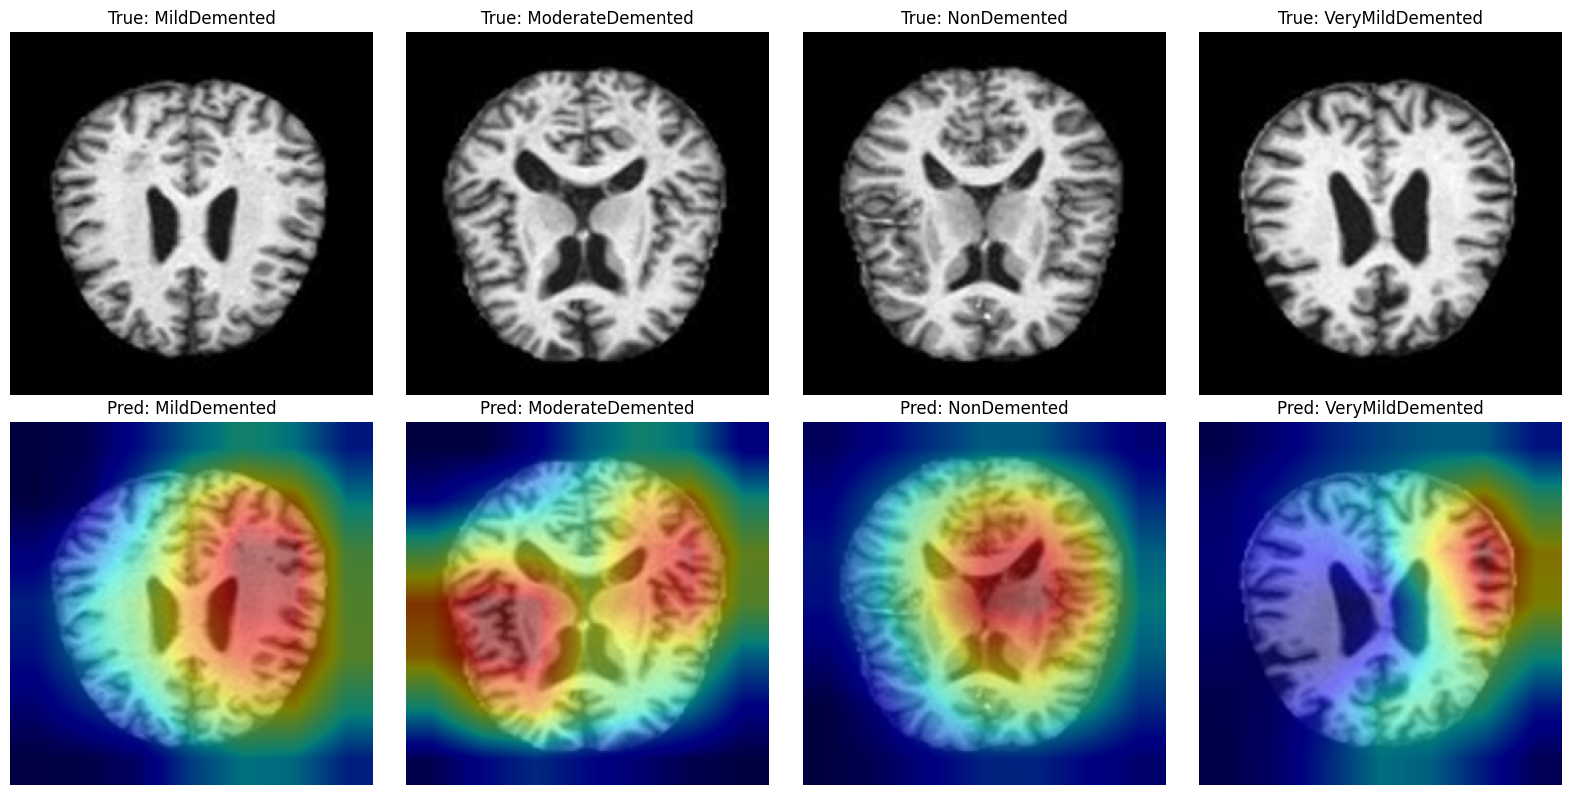

In [15]:
"""
Stage 5: Grad-CAM (self-contained, no extra library).

How it works, briefly: we hook layer4 (the last conv block) to
capture its activations during the forward pass, and its gradients
during the backward pass. For a chosen class, "how much did each
channel in layer4 matter for this prediction" is the gradient
averaged over space. Weighting each channel's activation map by
that importance, summing, and applying ReLU (we only care about
features that increased the score, not decreased it) gives the
Grad-CAM heatmap. We then resize it up to image size and overlay it.

Run this after Stage 3/4, in the same session, so best_model.pt exists.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        score = output[0, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, output.argmax(1).item()

def overlay_heatmap(original_img, cam):
    heatmap = cm.jet(cam)[:, :, :3]
    original = np.array(original_img.resize((224, 224)).convert("RGB")) / 255.0
    return 0.5 * original + 0.5 * heatmap

if __name__ == "__main__":
    model = build_model()
    model.load_state_dict(torch.load("best_model.pt"))
    model.eval()

    gradcam = GradCAM(model, model.layer4)

    df = pd.read_csv("splits/test.csv")
    # take one correctly-labeled example per class for a clean comparison grid
    sample_paths = df.groupby("label").first()["filepath"].to_dict()

    fig, axes = plt.subplots(2, len(CLASSES), figsize=(4 * len(CLASSES), 8))

    for i, (label, path) in enumerate(sample_paths.items()):
        img = Image.open(path)
        input_tensor = transform(img).unsqueeze(0).to(DEVICE)
        cam, pred_idx = gradcam.generate(input_tensor, LABEL_TO_IDX[label])
        overlay = overlay_heatmap(img, cam)

        axes[0, i].imshow(img.resize((224, 224)), cmap="gray")
        axes[0, i].set_title(f"True: {label}")
        axes[0, i].axis("off")

        axes[1, i].imshow(overlay)
        axes[1, i].set_title(f"Pred: {CLASSES[pred_idx]}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.savefig("gradcam_grid.png", dpi=150)
    print("Saved gradcam_grid.png")
    plt.show()

In [16]:
"""
Stage 6a: DCGAN for ModerateDemented augmentation.

Honest expectation: 44 real images is very little for GAN training.
Standard GANs are typically trained on thousands of images. We use a
small architecture and heavy standard augmentation (flips, rotations)
applied to the real images each epoch, which effectively shows the
discriminator more varied views of the same 44 images. This does not
fix the fundamental data scarcity, it just gives the GAN a slightly
better chance. If generated samples look like noise or collapse to
one repeated pattern, that IS the result, report it as such.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils as vutils
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 64
LATENT_DIM = 100
EPOCHS = 300
BATCH_SIZE = 8
N_SYNTHETIC = 200

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(1),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

class ModerateDataset(Dataset):
    def __init__(self, csv_path):
        df = pd.read_csv(csv_path)
        self.paths = df[df["label"] == "ModerateDemented"]["filepath"].tolist()

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        return train_transform(Image.open(self.paths[idx]))

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 1, 4, 1, 0), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1)

if __name__ == "__main__":
    dataset = ModerateDataset("splits/train.csv")
    print(f"Training GAN on {len(dataset)} real ModerateDemented images")
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    G, D = Generator().to(DEVICE), Discriminator().to(DEVICE)
    opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    for epoch in range(EPOCHS):
        for real in loader:
            real = real.to(DEVICE)
            bs = real.size(0)
            real_labels = torch.full((bs,), 0.9, device=DEVICE)  # label smoothing
            fake_labels = torch.zeros(bs, device=DEVICE)

            # train discriminator
            opt_d.zero_grad()
            d_real = D(real)
            loss_d_real = criterion(d_real, real_labels)
            z = torch.randn(bs, LATENT_DIM, 1, 1, device=DEVICE)
            fake = G(z)
            d_fake = D(fake.detach())
            loss_d_fake = criterion(d_fake, fake_labels)
            (loss_d_real + loss_d_fake).backward()
            opt_d.step()

            # train generator
            opt_g.zero_grad()
            d_fake_for_g = D(fake)
            loss_g = criterion(d_fake_for_g, torch.full((bs,), 0.9, device=DEVICE))
            loss_g.backward()
            opt_g.step()

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | D loss: {(loss_d_real+loss_d_fake).item():.3f} | G loss: {loss_g.item():.3f}")

    # save a visual grid to inspect before trusting these for anything
    z = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
    with torch.no_grad():
        samples = G(z).cpu()
    vutils.save_image(samples, "gan_samples_preview.png", normalize=True, nrow=4)
    print("Saved gan_samples_preview.png - LOOK AT THIS before proceeding")

    # generate the full synthetic set for later use, only if preview looks reasonable
    import os
    os.makedirs("synthetic_moderate", exist_ok=True)
    with torch.no_grad():
        for i in range(N_SYNTHETIC):
            z = torch.randn(1, LATENT_DIM, 1, 1, device=DEVICE)
            img = G(z).cpu()
            vutils.save_image(img, f"synthetic_moderate/synth_{i}.png", normalize=True)
    print(f"Saved {N_SYNTHETIC} synthetic images to synthetic_moderate/")

Training GAN on 56 real ModerateDemented images
Epoch 50/300 | D loss: 0.489 | G loss: 3.445
Epoch 100/300 | D loss: 0.597 | G loss: 3.514
Epoch 150/300 | D loss: 0.615 | G loss: 2.301
Epoch 200/300 | D loss: 0.697 | G loss: 3.741
Epoch 250/300 | D loss: 0.518 | G loss: 3.486
Epoch 300/300 | D loss: 0.494 | G loss: 3.586
Saved gan_samples_preview.png - LOOK AT THIS before proceeding
Saved 200 synthetic images to synthetic_moderate/


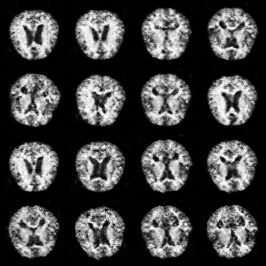

In [17]:
from IPython.display import Image, display

display(Image("gan_samples_preview.png"))

In [18]:
import os

print(os.listdir("synthetic_moderate")[:10])
print("Total:", len(os.listdir("synthetic_moderate")))

['synth_81.png', 'synth_102.png', 'synth_1.png', 'synth_48.png', 'synth_86.png', 'synth_68.png', 'synth_119.png', 'synth_127.png', 'synth_171.png', 'synth_170.png']
Total: 200


In [19]:
import os
print("Current directory:", os.getcwd())
print("Contents:", os.listdir("."))

Current directory: /kaggle/working
Contents: ['synthetic_moderate', 'best_model.pt', 'gan_samples_preview.png', 'gradcam_grid.png', '.virtual_documents', 'splits']


In [20]:
"""
Stage 6b: augmented manifest.

Critical rule: synthetic images go ONLY into the training set. Val
and test stay exactly as they were, real images only. Adding
synthetic images to evaluation data would make the comparison
meaningless, since we'd be testing the model partly on images it
was never meant to see as "ground truth."
"""

import os
import pandas as pd

SYNTH_DIR = "synthetic_moderate"
synth_paths = [os.path.join(SYNTH_DIR, f) for f in os.listdir(SYNTH_DIR) if f.endswith(".png")]

train_df = pd.read_csv("splits/train.csv")
synth_df = pd.DataFrame({
    "filepath": synth_paths,
    "label": "ModerateDemented",
})

augmented = pd.concat([train_df, synth_df], ignore_index=True)
augmented.to_csv("splits/train_augmented.csv", index=False)

print(f"Original train size: {len(train_df)}")
print(f"Added synthetic ModerateDemented: {len(synth_df)}")
print(f"Augmented train size: {len(augmented)}")
print(augmented["label"].value_counts())

Original train size: 5632
Added synthetic ModerateDemented: 200
Augmented train size: 5832
label
NonDemented         2826
VeryMildDemented    1978
MildDemented         772
ModerateDemented     256
Name: count, dtype: int64


In [21]:
"""
Stage 6c: train on augmented data, save separately as best_model_augmented.pt
so we keep the original baseline model (best_model.pt) intact for comparison.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def make_weighted_sampler(csv_path):
    df = pd.read_csv(csv_path)
    class_counts = df["label"].value_counts()
    weights = df["label"].apply(lambda c: 1.0 / class_counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return f1_score(targets, preds, average="macro")

def train(epochs=15, batch_size=32, lr=1e-4):
    train_ds = MRIDataset("splits/train_augmented.csv")
    val_ds = MRIDataset("splits/val.csv")

    sampler = make_weighted_sampler("splits/train_augmented.csv")
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_f1 = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_augmented.pt")

    print(f"\nBest val macro-F1: {best_f1:.4f}")

if __name__ == "__main__":
    train()

Epoch 1/15 | train loss: 0.4566 | val macro-F1: 0.6147
Epoch 2/15 | train loss: 0.1347 | val macro-F1: 0.6830
Epoch 3/15 | train loss: 0.0723 | val macro-F1: 0.7241
Epoch 4/15 | train loss: 0.0554 | val macro-F1: 0.7062
Epoch 5/15 | train loss: 0.0391 | val macro-F1: 0.8544
Epoch 6/15 | train loss: 0.0185 | val macro-F1: 0.5658
Epoch 7/15 | train loss: 0.0370 | val macro-F1: 0.8915
Epoch 8/15 | train loss: 0.0284 | val macro-F1: 0.8347
Epoch 9/15 | train loss: 0.0182 | val macro-F1: 0.8957
Epoch 10/15 | train loss: 0.0174 | val macro-F1: 0.7155
Epoch 11/15 | train loss: 0.0181 | val macro-F1: 0.8509
Epoch 12/15 | train loss: 0.0091 | val macro-F1: 0.8175
Epoch 13/15 | train loss: 0.0102 | val macro-F1: 0.7869
Epoch 14/15 | train loss: 0.0147 | val macro-F1: 0.7188
Epoch 15/15 | train loss: 0.0252 | val macro-F1: 0.7780

Best val macro-F1: 0.8957


In [22]:
"""
Stage 6d: evaluate augmented model on the same real test.csv (untouched).
Compare this directly against the baseline's 0.909 test macro-F1 and
[0.877, 0.936] CI from Stage 4.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 2000

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return np.array(preds), np.array(targets)

def bootstrap_macro_f1(preds, targets, n=N_BOOTSTRAP):
    n_samples = len(preds)
    rng = np.random.default_rng(42)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        scores.append(f1_score(targets[idx], preds[idx], average="macro"))
    return np.percentile(scores, [2.5, 50, 97.5])

if __name__ == "__main__":
    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)

    model = build_model()
    model.load_state_dict(torch.load("best_model_augmented.pt"))

    preds, targets = get_predictions(model, test_loader)
    point_f1 = f1_score(targets, preds, average="macro")
    ci_low, ci_mid, ci_high = bootstrap_macro_f1(preds, targets)

    print(f"[AUGMENTED MODEL] Test macro-F1: {point_f1:.3f}")
    print(f"Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}] (median {ci_mid:.3f})")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))
    print("\nCompare against baseline: test macro-F1 0.909, CI [0.877, 0.936]")

[AUGMENTED MODEL] Test macro-F1: 0.878
Bootstrap 95% CI: [0.838, 0.910] (median 0.877)

Full classification report:
                  precision    recall  f1-score   support

    MildDemented       0.93      0.65      0.76        60
ModerateDemented       1.00      1.00      1.00         4
     NonDemented       0.86      0.97      0.91       186
VeryMildDemented       0.86      0.82      0.84       133

        accuracy                           0.87       383
       macro avg       0.91      0.86      0.88       383
    weighted avg       0.87      0.87      0.86       383


Compare against baseline: test macro-F1 0.909, CI [0.877, 0.936]


In [23]:
"""
Stage 6e: paired bootstrap comparison.

Comparing two separate confidence intervals for overlap is a rough
heuristic, not a real test. The correct approach: for each bootstrap
resample of the test set, compute BOTH models' macro-F1 on the exact
same resampled indices, then look at the distribution of
(augmented - baseline). If that distribution's 95% CI includes 0,
the improvement is not statistically significant.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 2000

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def get_predictions(model_path, loader):
    model = build_model()
    model.load_state_dict(torch.load(model_path))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return np.array(preds), np.array(targets)

if __name__ == "__main__":
    test_loader = DataLoader(MRIDataset("splits/test.csv"), batch_size=32)

    preds_base, targets = get_predictions("best_model.pt", test_loader)
    preds_aug, _ = get_predictions("best_model_augmented.pt", test_loader)

    n = len(targets)
    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, n)
        f1_base = f1_score(targets[idx], preds_base[idx], average="macro")
        f1_aug = f1_score(targets[idx], preds_aug[idx], average="macro")
        diffs.append(f1_aug - f1_base)
    diffs = np.array(diffs)

    ci_low, ci_mid, ci_high = np.percentile(diffs, [2.5, 50, 97.5])
    pct_positive = (diffs > 0).mean() * 100

    print(f"Mean difference (augmented - baseline): {diffs.mean():.4f}")
    print(f"95% CI of difference: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"Augmented model wins in {pct_positive:.1f}% of bootstrap resamples")
    if ci_low <= 0 <= ci_high:
        print("\nCI includes 0: the improvement is NOT statistically significant.")
    else:
        print("\nCI excludes 0: the improvement IS statistically significant.")

Mean difference (augmented - baseline): 0.0186
95% CI of difference: [-0.0137, 0.0504]
Augmented model wins in 87.6% of bootstrap resamples

CI includes 0: the improvement is NOT statistically significant.


In [24]:
"""
Stage 6e: paired bootstrap comparison.

Comparing two separate confidence intervals for overlap is a rough
heuristic, not a real test. The correct approach: for each bootstrap
resample of the test set, compute BOTH models' macro-F1 on the exact
same resampled indices, then look at the distribution of
(augmented - baseline). If that distribution's 95% CI includes 0,
the improvement is not statistically significant.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 2000

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def get_predictions(model_path, loader):
    model = build_model()
    model.load_state_dict(torch.load(model_path))
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return np.array(preds), np.array(targets)

if __name__ == "__main__":
    test_loader = DataLoader(MRIDataset("splits/test.csv"), batch_size=32)

    preds_base, targets = get_predictions("best_model.pt", test_loader)
    preds_aug, _ = get_predictions("best_model_augmented.pt", test_loader)

    point_base = f1_score(targets, preds_base, average="macro")
    point_aug = f1_score(targets, preds_aug, average="macro")
    print(f"CURRENT baseline model test macro-F1 (live, this session): {point_base:.4f}")
    print(f"CURRENT augmented model test macro-F1 (live, this session): {point_aug:.4f}")
    print(f"Raw point difference: {point_aug - point_base:.4f}")
    print("(This should be close to the bootstrap mean difference below. "
          "If not, something is still inconsistent.)\n")

    n = len(targets)
    rng = np.random.default_rng(42)
    diffs = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, n, n)
        f1_base = f1_score(targets[idx], preds_base[idx], average="macro")
        f1_aug = f1_score(targets[idx], preds_aug[idx], average="macro")
        diffs.append(f1_aug - f1_base)
    diffs = np.array(diffs)

    ci_low, ci_mid, ci_high = np.percentile(diffs, [2.5, 50, 97.5])
    pct_positive = (diffs > 0).mean() * 100

    print(f"Mean difference (augmented - baseline): {diffs.mean():.4f}")
    print(f"95% CI of difference: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"Augmented model wins in {pct_positive:.1f}% of bootstrap resamples")
    if ci_low <= 0 <= ci_high:
        print("\nCI includes 0: the improvement is NOT statistically significant.")
    else:
        print("\nCI excludes 0: the improvement IS statistically significant.")

CURRENT baseline model test macro-F1 (live, this session): 0.8600
CURRENT augmented model test macro-F1 (live, this session): 0.8781
Raw point difference: 0.0181
(This should be close to the bootstrap mean difference below. If not, something is still inconsistent.)

Mean difference (augmented - baseline): 0.0186
95% CI of difference: [-0.0137, 0.0504]
Augmented model wins in 87.6% of bootstrap resamples

CI includes 0: the improvement is NOT statistically significant.


In [ ]:
"""
Stage 3: baseline CNN, no generative augmentation yet.

We want an honest baseline number before adding anything to fix the
class imbalance further. This baseline already includes weighted
sampling, since training without it would almost certainly produce
a model that just predicts NonDemented most of the time.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

torch.manual_seed(42)

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"])
        img = transform(img)
        label = LABEL_TO_IDX[row["label"]]
        return img, label

def make_weighted_sampler(csv_path):
    df = pd.read_csv(csv_path)
    class_counts = df["label"].value_counts()
    weights = df["label"].apply(lambda c: 1.0 / class_counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    macro_f1 = f1_score(targets, preds, average="macro")
    return macro_f1, preds, targets

def train(epochs=15, batch_size=32, lr=1e-4):
    train_ds = MRIDataset("splits/train.csv")
    val_ds = MRIDataset("splits/val.csv")

    sampler = make_weighted_sampler("splits/train.csv")
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_f1, _, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model.pt")

    print(f"\nBest val macro-F1: {best_f1:.4f}")
    return model

if __name__ == "__main__":
    model = train()

    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)
    model.load_state_dict(torch.load("best_model.pt"))
    test_f1, preds, targets = evaluate(model, test_loader)

    print(f"\nTest macro-F1: {test_f1:.4f}")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))

Epoch 1/15 | train loss: 0.4613 | val macro-F1: 0.6703
Epoch 2/15 | train loss: 0.1358 | val macro-F1: 0.7324
Epoch 3/15 | train loss: 0.0785 | val macro-F1: 0.8436
Epoch 4/15 | train loss: 0.0326 | val macro-F1: 0.7579
Epoch 5/15 | train loss: 0.0414 | val macro-F1: 0.8535
Epoch 6/15 | train loss: 0.0189 | val macro-F1: 0.8678
Epoch 7/15 | train loss: 0.0344 | val macro-F1: 0.8060
Epoch 8/15 | train loss: 0.0236 | val macro-F1: 0.8498
Epoch 9/15 | train loss: 0.0226 | val macro-F1: 0.8834
Epoch 10/15 | train loss: 0.0093 | val macro-F1: 0.8677
Epoch 11/15 | train loss: 0.0067 | val macro-F1: 0.8501
Epoch 12/15 | train loss: 0.0147 | val macro-F1: 0.8674
Epoch 13/15 | train loss: 0.0037 | val macro-F1: 0.8423
Epoch 14/15 | train loss: 0.0151 | val macro-F1: 0.8551


In [ ]:
"""
Stage 6c: train on augmented data, save separately as best_model_augmented.pt
so we keep the original baseline model (best_model.pt) intact for comparison.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score

torch.manual_seed(42)

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def make_weighted_sampler(csv_path):
    df = pd.read_csv(csv_path)
    class_counts = df["label"].value_counts()
    weights = df["label"].apply(lambda c: 1.0 / class_counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def evaluate(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return f1_score(targets, preds, average="macro")

def train(epochs=15, batch_size=32, lr=1e-4):
    train_ds = MRIDataset("splits/train_augmented.csv")
    val_ds = MRIDataset("splits/val.csv")

    sampler = make_weighted_sampler("splits/train_augmented.csv")
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1 = 0.0
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        val_f1 = evaluate(model, val_loader)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {total_loss/len(train_loader):.4f} | val macro-F1: {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_augmented.pt")

    print(f"\nBest val macro-F1: {best_f1:.4f}")

if __name__ == "__main__":
    train()

In [ ]:
"""
Stage 4: evaluation with bootstrap CIs (self-contained version).

Run this after training with stage3_train_baseline.py in the same
notebook session, so best_model.pt already exists in the working
directory. This version duplicates the small pieces it needs instead
of importing stage3 as a module, since Kaggle notebook cells aren't
separate importable files by default.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 2000

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return np.array(preds), np.array(targets)

def bootstrap_macro_f1(preds, targets, n=N_BOOTSTRAP):
    n_samples = len(preds)
    rng = np.random.default_rng(42)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        scores.append(f1_score(targets[idx], preds[idx], average="macro"))
    return np.percentile(scores, [2.5, 50, 97.5])

if __name__ == "__main__":
    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)

    model = build_model()
    model.load_state_dict(torch.load("best_model.pt"))

    preds, targets = get_predictions(model, test_loader)

    point_f1 = f1_score(targets, preds, average="macro")
    ci_low, ci_mid, ci_high = bootstrap_macro_f1(preds, targets)

    print(f"Test macro-F1: {point_f1:.3f}")
    print(f"Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}] (median {ci_mid:.3f})")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))
    print("\nNote: ModerateDemented has only 4 test images. Its per-class "
          "precision/recall should be read as a rough signal, not a precise "
          "estimate, given the sample size.")

In [ ]:
"""
Stage 6d: evaluate augmented model on the same real test.csv (untouched).
Compare this directly against the baseline's 0.909 test macro-F1 and
[0.877, 0.936] CI from Stage 4.
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score, classification_report

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_BOOTSTRAP = 2000

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = transform(Image.open(row["filepath"]))
        return img, LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return np.array(preds), np.array(targets)

def bootstrap_macro_f1(preds, targets, n=N_BOOTSTRAP):
    n_samples = len(preds)
    rng = np.random.default_rng(42)
    scores = []
    for _ in range(n):
        idx = rng.integers(0, n_samples, n_samples)
        scores.append(f1_score(targets[idx], preds[idx], average="macro"))
    return np.percentile(scores, [2.5, 50, 97.5])

if __name__ == "__main__":
    test_ds = MRIDataset("splits/test.csv")
    test_loader = DataLoader(test_ds, batch_size=32)

    model = build_model()
    model.load_state_dict(torch.load("best_model_augmented.pt"))

    preds, targets = get_predictions(model, test_loader)
    point_f1 = f1_score(targets, preds, average="macro")
    ci_low, ci_mid, ci_high = bootstrap_macro_f1(preds, targets)

    print(f"[AUGMENTED MODEL] Test macro-F1: {point_f1:.3f}")
    print(f"Bootstrap 95% CI: [{ci_low:.3f}, {ci_high:.3f}] (median {ci_mid:.3f})")
    print("\nFull classification report:")
    print(classification_report(targets, preds, target_names=CLASSES))
    print("\nCompare against baseline: test macro-F1 0.909, CI [0.877, 0.936]")

In [ ]:
"""
Stage 7: multi-seed comparison.

A single paired bootstrap only captures uncertainty from which test
images we happened to draw. It says nothing about uncertainty from
which random training run we happened to get, and we just proved
that source of variance is real and large enough to flip our
conclusion. The correct fix: train each model multiple times with
different seeds, and look at the SPREAD of results, not one run.

With only 3 seeds, a formal significance test has very little power,
so we report the raw per-seed results and the paired differences
directly, and let the spread speak for itself, rather than compute
a p-value that would overstate precision we don't have.
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import f1_score

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEEDS = [42, 123, 2024]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return transform(Image.open(row["filepath"])), LABEL_TO_IDX[row["label"]]

def make_weighted_sampler(csv_path):
    df = pd.read_csv(csv_path)
    class_counts = df["label"].value_counts()
    weights = df["label"].apply(lambda c: 1.0 / class_counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

def evaluate_f1(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())
    return f1_score(targets, preds, average="macro")

def train_one_run(train_csv, seed, epochs=15, batch_size=32, lr=1e-4):
    torch.manual_seed(seed)
    train_ds = MRIDataset(train_csv)
    val_ds = MRIDataset("splits/val.csv")
    sampler = make_weighted_sampler(train_csv)
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    val_loader = DataLoader(val_ds, batch_size=batch_size)

    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_f1, best_state = 0.0, None
    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
        val_f1 = evaluate_f1(model, val_loader)
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

if __name__ == "__main__":
    test_loader = DataLoader(MRIDataset("splits/test.csv"), batch_size=32)

    results = []
    for seed in SEEDS:
        print(f"\n=== Seed {seed}: baseline ===")
        base_model = train_one_run("splits/train.csv", seed)
        base_f1 = evaluate_f1(base_model, test_loader)
        print(f"Seed {seed} baseline test macro-F1: {base_f1:.4f}")

        print(f"=== Seed {seed}: augmented ===")
        aug_model = train_one_run("splits/train_augmented.csv", seed)
        aug_f1 = evaluate_f1(aug_model, test_loader)
        print(f"Seed {seed} augmented test macro-F1: {aug_f1:.4f}")

        results.append((seed, base_f1, aug_f1, aug_f1 - base_f1))

    print("\n" + "=" * 60)
    print("SUMMARY: seed | baseline | augmented | difference")
    print("=" * 60)
    diffs = []
    for seed, base_f1, aug_f1, diff in results:
        print(f"{seed:6d} | {base_f1:.4f}   | {aug_f1:.4f}    | {diff:+.4f}")
        diffs.append(diff)

    import numpy as np
    diffs = np.array(diffs)
    print(f"\nMean difference across {len(SEEDS)} seeds: {diffs.mean():+.4f}")
    print(f"Std across seeds: {diffs.std():.4f}")
    print(f"Positive (augmentation helped) in {(diffs > 0).sum()}/{len(SEEDS)} seeds")
    print("\nNote: with only 3 seeds this is a descriptive summary of the "
          "spread, not a formal significance test.")

In [ ]:
import os
print(os.getcwd())
print(os.listdir("."))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

CLASSES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

fig, ax = plt.subplots(figsize=(9, 5))
width = 0.25
x = range(len(CLASSES))

for i, split in enumerate(["train", "val", "test"]):
    df = pd.read_csv(f"splits/{split}.csv")
    counts = df["label"].value_counts().reindex(CLASSES).fillna(0)
    ax.bar([p + i * width for p in x], counts, width, label=split)

ax.set_xticks([p + width for p in x])
ax.set_xticklabels(CLASSES, rotation=15)
ax.set_ylabel("Number of images")
ax.set_title("Class distribution across splits (leakage-safe, group-based)")
ax.legend()
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
print("Saved class_distribution.png")

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class MRIDataset(Dataset):
    def __init__(self, csv_path):
        self.df = pd.read_csv(csv_path)
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return transform(Image.open(row["filepath"])), LABEL_TO_IDX[row["label"]]

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

if __name__ == "__main__":
    model = build_model()
    model.load_state_dict(torch.load("best_model.pt"))
    model.eval()

    loader = DataLoader(MRIDataset("splits/test.csv"), batch_size=32)
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            outputs = model(imgs)
            preds.extend(outputs.argmax(1).cpu().tolist())
            targets.extend(labels.tolist())

    cm = confusion_matrix(targets, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(CLASSES)))
    ax.set_yticks(range(len(CLASSES)))
    ax.set_xticklabels(CLASSES, rotation=30, ha="right")
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion matrix (row-normalized), baseline model")

    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)",
                     ha="center", va="center",
                     color="white" if cm_norm[i, j] > 0.5 else "black")

    plt.colorbar(im, label="Row-normalized proportion")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    print("Saved confusion_matrix.png")

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_PER_CLASS = 4

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def build_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(DEVICE)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

def overlay(img, cam_map):
    heatmap = cm.jet(cam_map)[:, :, :3]
    base = np.array(img.resize((224, 224)).convert("RGB")) / 255.0
    return 0.5 * base + 0.5 * heatmap

if __name__ == "__main__":
    model = build_model()
    model.load_state_dict(torch.load("best_model.pt"))
    model.eval()
    gradcam = GradCAM(model, model.layer4)

    df = pd.read_csv("splits/test.csv")
    fig, axes = plt.subplots(len(CLASSES), N_PER_CLASS, figsize=(3 * N_PER_CLASS, 3 * len(CLASSES)))

    for row, label in enumerate(CLASSES):
        paths = df[df["label"] == label]["filepath"].head(N_PER_CLASS).tolist()
        for col, path in enumerate(paths):
            img = Image.open(path)
            input_tensor = transform(img).unsqueeze(0).to(DEVICE)
            cam_map = gradcam.generate(input_tensor, LABEL_TO_IDX[label])
            axes[row, col].imshow(overlay(img, cam_map))
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_ylabel(label, fontsize=10)
        axes[row, 0].text(-30, 112, label, rotation=90, va="center", fontsize=11)

    plt.suptitle("Grad-CAM across multiple examples per class")
    plt.tight_layout()
    plt.savefig("gradcam_grid_expanded.png", dpi=150)
    print("Saved gradcam_grid_expanded.png")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# from your Stage 7 output, no retraining needed
seeds = [42, 123, 2024]
baseline = [0.9085, 0.9184, 0.8899]
augmented = [0.8621, 0.8885, 0.8674]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(seeds))
width = 0.35

ax.bar(x - width/2, baseline, width, label="Baseline", color="#4C72B0")
ax.bar(x + width/2, augmented, width, label="+ GAN augmentation", color="#DD8452")

for i in range(len(seeds)):
    ax.text(x[i] - width/2, baseline[i] + 0.005, f"{baseline[i]:.3f}", ha="center", fontsize=9)
    ax.text(x[i] + width/2, augmented[i] + 0.005, f"{augmented[i]:.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f"Seed {s}" for s in seeds])
ax.set_ylabel("Test macro-F1")
ax.set_ylim(0.80, 0.95)
ax.set_title("Baseline consistently outperforms augmented model across all 3 seeds")
ax.legend()
plt.tight_layout()
plt.savefig("multiseed_comparison.png", dpi=150)
print("Saved multiseed_comparison.png")